## Importing Libraries

In [1]:
#!pip install --upgrade xport

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline
#from google.colab import drive

In [3]:
#drive.mount('/content/drive')

In [4]:
#df = pd.read_csv("/content/drive/My Drive/churn_data.csv")
df = pd.read_csv("churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.drop('customerID',axis='columns', inplace=True)

In [6]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df['TotalCharges'].values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #The errors='coerce' argument will replace any invalid values with NaN.

In [9]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Data Pre-Processing

In [10]:
df.TotalCharges.values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [11]:
df.iloc[488]['TotalCharges']

nan

In [12]:
df.TotalCharges = df.TotalCharges.fillna(df.TotalCharges.median())

In [13]:
pd.to_numeric(df.TotalCharges,errors='coerce').isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

In [14]:
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [15]:
df.shape

(7043, 20)

In [16]:
df.iloc[488]['TotalCharges']

1397.475

In [17]:
df[df.TotalCharges!=' '].shape

(7043, 20)

Remove all Nan Values from Total Charges

In [18]:
df1=df[df.TotalCharges!=np.nan]
df1.shape

(7043, 20)

In [19]:
df1.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [20]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

In [21]:
df1.TotalCharges.values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [22]:
df1.iloc[488]['TotalCharges']

1397.475

In [23]:
df1[df1.Churn=='No']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


## Exploratory Data Analysis

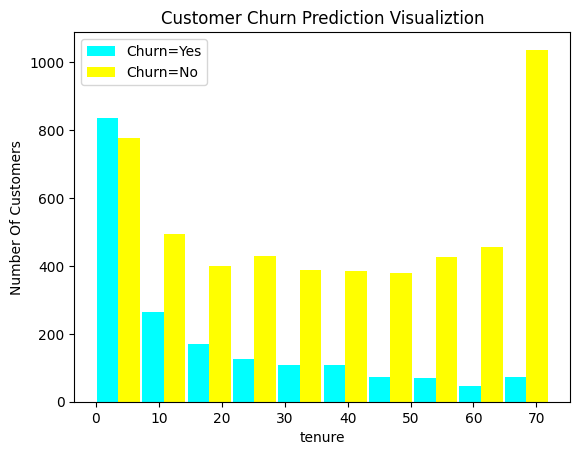

In [24]:
tenure_churn_no = df1[df1.Churn=='No'].tenure
tenure_churn_yes = df1[df1.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['cyan','yellow'],label=['Churn=Yes','Churn=No'])
plt.legend()

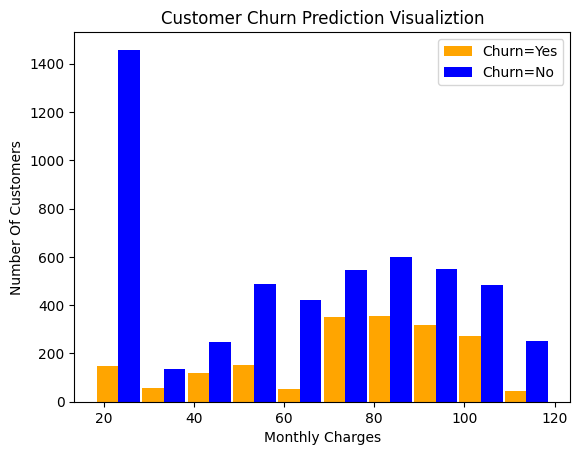

In [25]:
mc_churn_no = df1[df1.Churn=='No'].MonthlyCharges
mc_churn_yes = df1[df1.Churn=='Yes'].MonthlyCharges

plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['orange','blue'],label=['Churn=Yes','Churn=No'])
plt.legend()

In [26]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}')

In [27]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [28]:
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)

In [29]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [30]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df1[col].replace({'Yes': 1,'No': 0},inplace=True)

C:\Users\laksh\AppData\Local\Temp\ipykernel_17188\1648037665.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].replace({'Yes': 1,'No': 0},inplace=True)
C:\Users\laksh\AppData\Local\Temp\ipykernel_17188\1648037665.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col].replace({'Yes':

In [31]:
for col in df1:
    print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


In [32]:
df1['gender'].replace({'Female':1,'Male':0},inplace=True)

C:\Users\laksh\AppData\Local\Temp\ipykernel_17188\698335744.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].replace({'Female':1,'Male':0},inplace=True)
C:\Users\laksh\AppData\Local\Temp\ipykernel_17188\698335744.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['gender'].repl

In [33]:
df1.gender.unique()

array([1, 0], dtype=int64)

In [34]:
df1.gender.dtypes

dtype('int64')

In [35]:
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


One hot encoding

In [36]:
df2 = pd.get_dummies(data=df1, columns=['InternetService','Contract','PaymentMethod'])
df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [37]:
df2.shape

(7043, 27)

In [38]:
df2.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2119,0,0,1,1,46,1,0,0,0,0,...,False,False,True,False,True,False,True,False,False,False
1574,1,0,0,1,15,1,0,0,0,0,...,False,False,True,False,True,False,False,False,False,True
2316,0,0,0,0,4,1,0,0,0,0,...,False,False,True,True,False,False,False,False,False,True
4373,1,0,1,1,25,1,0,0,0,0,...,False,False,True,False,True,False,False,False,False,True
5340,1,0,0,0,38,1,1,1,1,1,...,True,False,False,False,True,False,True,False,False,False


In [39]:
df2.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No             

In [40]:
cols_scale=['tenure','MonthlyCharges','TotalCharges']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2[cols_scale] = scaler.fit_transform(df2[cols_scale])

In [41]:
for cols in df2:
    print(f'{cols}: {df2[cols].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.01388889 0.47222222 0.02777778 0.625      0.11111111 0.30555556
 0.13888889 0.38888889 0.86111111 0.18055556 0.22222222 0.80555556
 0.68055556 0.34722222 0.95833333 0.72222222 0.98611111 0.29166667
 0.16666667 0.41666667 0.65277778 1.         0.23611111 0.375
 0.06944444 0.63888889 0.15277778 0.97222222 0.875      0.59722222
 0.20833333 0.83333333 0.25       0.91666667 0.125      0.04166667
 0.43055556 0.69444444 0.88888889 0.77777778 0.09722222 0.58333333
 0.48611111 0.66666667 0.40277778 0.90277778 0.52777778 0.94444444
 0.44444444 0.76388889 0.51388889 0.5        0.56944444 0.08333333
 0.05555556 0.45833333 0.93055556 0.31944444 0.79166667 0.84722222
 0.19444444 0.27777778 0.73611111 0.55555556 0.81944444 0.33333333
 0.61111111 0.26388889 0.75       0.70833333 0.36111111 0.
 0.54166667]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: 

In [42]:
col_bool=['InternetService_DSL','InternetService_Fiber optic', 'InternetService_No','Contract_Month-to-month','Contract_One year','Contract_Two year','PaymentMethod_Bank transfer (automatic)','PaymentMethod_Credit card (automatic)',
          'PaymentMethod_Electronic check','PaymentMethod_Mailed check']
for x in col_bool:
    df2[x].replace({True:1,False:0},inplace=True)

C:\Users\laksh\AppData\Local\Temp\ipykernel_17188\423665509.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[x].replace({True:1,False:0},inplace=True)
C:\Users\laksh\AppData\Local\Temp\ipykernel_17188\423665509.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[x].replace({True:1,False:0

In [43]:
for col in df2:
    print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.01388889 0.47222222 0.02777778 0.625      0.11111111 0.30555556
 0.13888889 0.38888889 0.86111111 0.18055556 0.22222222 0.80555556
 0.68055556 0.34722222 0.95833333 0.72222222 0.98611111 0.29166667
 0.16666667 0.41666667 0.65277778 1.         0.23611111 0.375
 0.06944444 0.63888889 0.15277778 0.97222222 0.875      0.59722222
 0.20833333 0.83333333 0.25       0.91666667 0.125      0.04166667
 0.43055556 0.69444444 0.88888889 0.77777778 0.09722222 0.58333333
 0.48611111 0.66666667 0.40277778 0.90277778 0.52777778 0.94444444
 0.44444444 0.76388889 0.51388889 0.5        0.56944444 0.08333333
 0.05555556 0.45833333 0.93055556 0.31944444 0.79166667 0.84722222
 0.19444444 0.27777778 0.73611111 0.55555556 0.81944444 0.33333333
 0.61111111 0.26388889 0.75       0.70833333 0.36111111 0.
 0.54166667]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: 

In [44]:
df2.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No             

## Split to test and train

In [45]:
x_churn=df2[df2.Churn==1]
x_nonchurn=df2[df2.Churn==0]
X = df2.drop('Churn',axis='columns')
y = df2['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
x_churn=x_churn.drop('Churn',axis='columns')
x_nonchurn=x_nonchurn.drop('Churn',axis='columns')

In [46]:
print(type(df2))
print(type(x_churn))
print(type(x_nonchurn))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [47]:
X_train.shape

(5634, 26)

In [48]:
X_test.shape

(1409, 26)

In [49]:
X_train[:10]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2142,1,0,0,1,0.291667,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
1623,1,0,0,0,0.750000,1,1,0,1,0,...,0,1,0,0,0,1,1,0,0,0
6074,0,0,1,0,0.013889,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
1362,0,0,0,0,0.055556,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
6754,0,0,0,1,0.000000,1,1,1,1,0,...,1,0,0,0,0,1,1,0,0,0
1212,0,0,0,0,0.097222,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
2722,0,0,1,1,0.444444,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
4006,0,0,1,1,1.000000,1,0,0,0,0,...,0,0,1,0,0,1,0,1,0,0
6791,0,0,0,0,0.263889,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
5466,0,0,0,1,0.138889,1,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0


In [50]:
len(X_train.columns)

26

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [52]:
class ChurnPred(nn.Module):
    def __init__(self):
        super(ChurnPred, self).__init__()
        #layers
        self.fc1 = nn.Linear(26, 20)
        self.dropout1 = nn.Dropout(0.2)
        
        self.fc2 = nn.Linear(20, 15)
        self.dropout2 = nn.Dropout(0.2)
        
        self.fc3 = nn.Linear(15, 1)
        
    def forward(self, x):
        # Layer 1 with ReLU activation and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        
        # Layer 2 with ReLU activation and dropout
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        # Output layer with Sigmoid activation
        x = torch.sigmoid(self.fc3(x))
        return x


In [53]:
# Early Stopping Implementation
class EarlyStopping:
    def __init__(self, patience=10, delta=0):
        self.patience = patience  # Number of epochs to wait for improvement
        self.delta = delta  # Minimum change to qualify as an improvement
        self.best_loss = np.inf  # Initialize with a very high loss value
        self.counter = 0  # Counter to track how many epochs without improvement

    def should_stop(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss  # Update the best loss if improvement
            self.counter = 0  # Reset the counter if there is improvement
            return False
        else:
            self.counter += 1  # Increment counter if no improvement
            if self.counter >= self.patience:  # Stop training if patience exceeded
                return True
            return False




In [54]:
# Initialize the model, criterion, optimizer, and early stopping
model = ChurnPred()  # Create the churn prediction model
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)  # Adam optimizer with L2 regularization
early_stopping = EarlyStopping(patience=10, delta=0.01)  # Patience of 10 epochs

# Convert to tensors (assuming you have X_train, y_train, X_test, y_test as pandas DataFrames)
train_inputs = torch.tensor(X_train.values, dtype=torch.float32)
train_labels = torch.tensor(y_train.values, dtype=torch.float32)
val_inputs = torch.tensor(X_test.values, dtype=torch.float32)
val_labels = torch.tensor(y_test.values, dtype=torch.float32)


In [55]:
# Create DataLoader for training
batch_size = 32
train_data = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Training Loop with Early Stopping
epochs = 100
for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels.unsqueeze(1))
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Validation Accuracy
    if (epoch + 1) % 10 == 0:
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels.unsqueeze(1))
            val_preds = (val_outputs > 0.5).float()
            val_accuracy = (val_preds.squeeze() == val_labels).float().mean()
        
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {running_loss/len(train_loader):.4f}, "
              f"Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Check early stopping condition
        if early_stopping.should_stop(val_loss.item()):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break  # Exit the training loop if early stopping is triggered

Epoch [10/100], Training Loss: 0.4298, Validation Loss: 0.4019, Validation Accuracy: 0.8204
Epoch [20/100], Training Loss: 0.4210, Validation Loss: 0.4000, Validation Accuracy: 0.8119
Epoch [30/100], Training Loss: 0.4154, Validation Loss: 0.4025, Validation Accuracy: 0.8077
Epoch [40/100], Training Loss: 0.4111, Validation Loss: 0.4034, Validation Accuracy: 0.8027
Epoch [50/100], Training Loss: 0.4062, Validation Loss: 0.4046, Validation Accuracy: 0.8034
Epoch [60/100], Training Loss: 0.4048, Validation Loss: 0.4047, Validation Accuracy: 0.8041
Epoch [70/100], Training Loss: 0.4017, Validation Loss: 0.4047, Validation Accuracy: 0.8105
Epoch [80/100], Training Loss: 0.3991, Validation Loss: 0.4053, Validation Accuracy: 0.8098
Epoch [90/100], Training Loss: 0.4046, Validation Loss: 0.4049, Validation Accuracy: 0.8105
Epoch [100/100], Training Loss: 0.4000, Validation Loss: 0.4065, Validation Accuracy: 0.8048


In [56]:
with torch.no_grad():
    y_predicted = model(torch.tensor(X_test.values, dtype=torch.float32))
    y_predicted_cls = y_predicted.round()
    acc = y_predicted_cls.eq(torch.tensor(y_test.values).unsqueeze(1)).sum() / float(y_test.shape[0])
    print(f'Accuracy: {acc:.4f}')

Accuracy: 0.8048


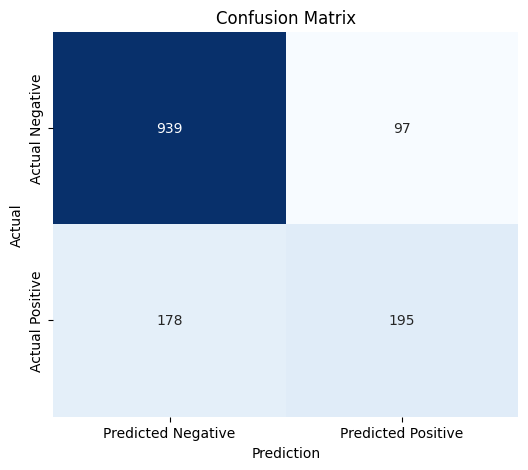

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Ensure the model is in evaluation mode
model.eval()

# Get predictions for the validation set
with torch.no_grad():
    val_outputs = model(val_inputs)
    val_preds = (val_outputs > 0.5).float()  # Convert probabilities to binary predictions (0 or 1)

# Convert predictions and labels to numpy arrays
val_preds_np = val_preds.squeeze().cpu().numpy()
val_labels_np = val_labels.cpu().numpy()

# Generate the confusion matrix
conf_matrix = confusion_matrix(val_labels_np, val_preds_np)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [58]:
from sklearn.metrics import classification_report, confusion_matrix

In [59]:
y_true = torch.tensor(y_test.values).unsqueeze(1)  # True labels as a tensor
y_pred = y_predicted_cls.numpy().flatten()  # Flatten predictions
y_true = y_true.numpy().flatten()  # Flatten true labels

In [60]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()  # Get the values from the confusion matrix

In [61]:
# Print confusion matrix values
print(f'True Negative (TN): {tn}')
print(f'False Positive (FP): {fp}')
print(f'False Negative (FN): {fn}')
print(f'True Positive (TP): {tp}')

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

True Negative (TN): 939
False Positive (FP): 97
False Negative (FN): 178
True Positive (TP): 195

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.52      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [62]:
#SMOTE
## Change to SMOTE
from imblearn.combine import SMOTEENN
from collections import Counter
st=SMOTEENN()
X_train_st,y_train_st = st.fit_resample(X_train, y_train)
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_st)))

The number of classes before fit Counter({0: 4138, 1: 1496})
The number of classes after fit Counter({1: 2762, 0: 2210})


In [63]:
# splitting the over sampling dataset
X_train_sap, X_test_sap, y_train_sap, y_test_sap = train_test_split(X_train_st, y_train_st, test_size=0.2)

In [64]:
print(type(X_train_sap))
print(X_train_sap.shape)
print(X_test_sap.shape)

<class 'pandas.core.frame.DataFrame'>
(3977, 26)
(995, 26)


In [65]:
# Initialize the model, criterion, optimizer, and early stopping
model = ChurnPred()  # Create the churn prediction model
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)  # Adam optimizer with L2 regularization
early_stopping = EarlyStopping(patience=10, delta=0.01)  # Patience of 10 epochs

# Convert to tensors (assuming you have X_train_sap, y_train_sap, X_test_sap, y_test_sap as pandas DataFrames)
train_inputs = torch.tensor(X_train_sap.values, dtype=torch.float32)
train_labels = torch.tensor(y_train_sap.values, dtype=torch.float32)
val_inputs = torch.tensor(X_test_sap.values, dtype=torch.float32)
val_labels = torch.tensor(y_test_sap.values, dtype=torch.float32)

In [66]:
# Create DataLoader for training
batch_size = 32
train_data = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Training Loop with Early Stopping
epochs = 100
for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels.unsqueeze(1))
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Validation Accuracy
    if (epoch + 1) % 10 == 0:
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels.unsqueeze(1))
            val_preds = (val_outputs > 0.5).float()
            val_accuracy = (val_preds.squeeze() == val_labels).float().mean()
        
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {running_loss/len(train_loader):.4f}, "
              f"Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Check early stopping condition
        if early_stopping.should_stop(val_loss.item()):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break  # Exit the training loop if early stopping is triggered

Epoch [10/100], Training Loss: 0.1991, Validation Loss: 0.1940, Validation Accuracy: 0.9266
Epoch [20/100], Training Loss: 0.1800, Validation Loss: 0.1815, Validation Accuracy: 0.9276
Epoch [30/100], Training Loss: 0.1623, Validation Loss: 0.1757, Validation Accuracy: 0.9307
Epoch [40/100], Training Loss: 0.1515, Validation Loss: 0.1672, Validation Accuracy: 0.9367
Epoch [50/100], Training Loss: 0.1446, Validation Loss: 0.1630, Validation Accuracy: 0.9347
Epoch [60/100], Training Loss: 0.1345, Validation Loss: 0.1565, Validation Accuracy: 0.9397
Epoch [70/100], Training Loss: 0.1294, Validation Loss: 0.1533, Validation Accuracy: 0.9427
Epoch [80/100], Training Loss: 0.1292, Validation Loss: 0.1501, Validation Accuracy: 0.9417
Epoch [90/100], Training Loss: 0.1198, Validation Loss: 0.1529, Validation Accuracy: 0.9417
Epoch [100/100], Training Loss: 0.1158, Validation Loss: 0.1545, Validation Accuracy: 0.9377


In [67]:
with torch.no_grad():
    # Use the oversampled test set for prediction
    y_predicted = model(torch.tensor(X_test_sap.values, dtype=torch.float32))
    
    # Round the predicted values to get class predictions
    y_predicted_cls = y_predicted.round()

    # Calculate accuracy by comparing predictions with true labels
    acc = y_predicted_cls.eq(torch.tensor(y_test_sap.values).unsqueeze(1)).sum() / float(y_test_sap.shape[0])

    # Print the accuracy
    print(f'Accuracy: {acc:.4f}')

Accuracy: 0.9377


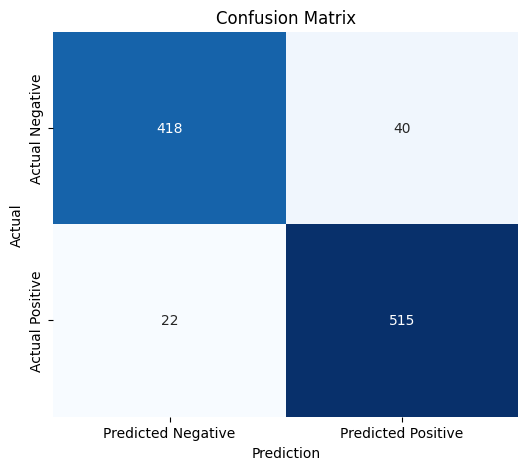

In [68]:
# Ensure the model is in evaluation mode
model.eval()

# Get predictions for the validation set
with torch.no_grad():
    val_outputs = model(val_inputs)
    val_preds = (val_outputs > 0.5).float()  # Convert probabilities to binary predictions (0 or 1)

# Convert predictions and labels to numpy arrays
val_preds_np = val_preds.squeeze().cpu().numpy()
val_labels_np = val_labels.cpu().numpy()

# Generate the confusion matrix
conf_matrix = confusion_matrix(val_labels_np, val_preds_np)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [69]:
y_true = torch.tensor(y_test_sap.values).unsqueeze(1)  # True labels as a tensor
y_pred = y_predicted_cls.numpy().flatten()  # Flatten predictions
y_true = y_true.numpy().flatten()  # Flatten true labels

In [70]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()  # Get the values from the confusion matrix

In [71]:
# Print confusion matrix values
print(f'True Negative (TN): {tn}')
print(f'False Positive (FP): {fp}')
print(f'False Negative (FN): {fn}')
print(f'True Positive (TP): {tp}')

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

True Negative (TN): 418
False Positive (FP): 40
False Negative (FN): 22
True Positive (TP): 515

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       458
           1       0.93      0.96      0.94       537

    accuracy                           0.94       995
   macro avg       0.94      0.94      0.94       995
weighted avg       0.94      0.94      0.94       995



In [72]:
import quantus
from captum.attr import IntegratedGradients

In [73]:
# Integrated Gradients explainer
ig = IntegratedGradients(model)

In [74]:
# Function to get the average attributions for the entire dataset
def explain_model(X_data, y_data):
    # Store the attributions for all samples
    total_attributions = torch.zeros(X_data.shape[1])

    # Loop through the test set and calculate attributions for each sample
    for i in range(X_data.shape[0]):
        input_sample = torch.tensor(X_data.iloc[i].values, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
        
        # Generate the attribution for the input sample
        attributions, delta = ig.attribute(input_sample, target=0, return_convergence_delta=True)
        
        # Accumulate the attributions for averaging
        total_attributions += attributions.squeeze()  # Remove extra dimension

    # Average the attributions across all samples
    average_attributions = total_attributions / X_data.shape[0]

    return average_attributions.detach().numpy()

Average attributions for each feature:
Feature: gender, Attribution: -0.0121
Feature: SeniorCitizen, Attribution: 0.0002
Feature: Partner, Attribution: -0.0017
Feature: Dependents, Attribution: -0.0442
Feature: tenure, Attribution: -0.0986
Feature: PhoneService, Attribution: -0.0533
Feature: MultipleLines, Attribution: -0.0069
Feature: OnlineSecurity, Attribution: -0.0285
Feature: OnlineBackup, Attribution: -0.0250
Feature: DeviceProtection, Attribution: -0.0234
Feature: TechSupport, Attribution: -0.0286
Feature: StreamingTV, Attribution: 0.0139
Feature: StreamingMovies, Attribution: 0.0167
Feature: PaperlessBilling, Attribution: 0.0070
Feature: MonthlyCharges, Attribution: 0.1234
Feature: TotalCharges, Attribution: 0.0476
Feature: InternetService_DSL, Attribution: 0.0257
Feature: InternetService_Fiber optic, Attribution: 0.0097
Feature: InternetService_No, Attribution: -0.0133
Feature: Contract_Month-to-month, Attribution: 0.0192
Feature: Contract_One year, Attribution: -0.0611
Featur

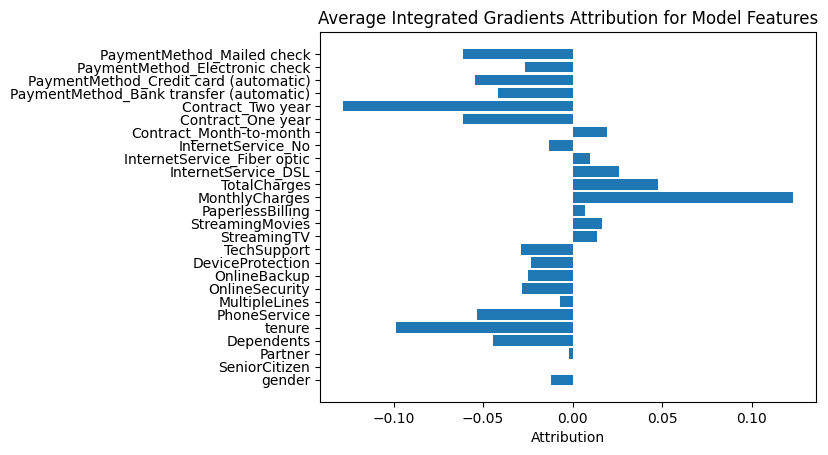

In [75]:
# Get the average attributions for the entire test set
average_attributions = explain_model(X_test_sap, y_test_sap)

# Print the attributions for each feature
print("Average attributions for each feature:")
for feature, attribution in zip(X_test_sap.columns, average_attributions):
    print(f"Feature: {feature}, Attribution: {attribution:.4f}")

# Visualize the average attributions
plt.barh(X_test_sap.columns, average_attributions)
plt.xlabel('Attribution')
plt.title('Average Integrated Gradients Attribution for Model Features')
plt.show()

Faithfulness Score (Pearson Correlation between predictions and summed attributions): 0.9997
Average attributions for each feature:
Feature: gender, Attribution: -0.0121
Feature: SeniorCitizen, Attribution: 0.0002
Feature: Partner, Attribution: -0.0017
Feature: Dependents, Attribution: -0.0442
Feature: tenure, Attribution: -0.0986
Feature: PhoneService, Attribution: -0.0533
Feature: MultipleLines, Attribution: -0.0069
Feature: OnlineSecurity, Attribution: -0.0285
Feature: OnlineBackup, Attribution: -0.0250
Feature: DeviceProtection, Attribution: -0.0234
Feature: TechSupport, Attribution: -0.0286
Feature: StreamingTV, Attribution: 0.0139
Feature: StreamingMovies, Attribution: 0.0167
Feature: PaperlessBilling, Attribution: 0.0070
Feature: MonthlyCharges, Attribution: 0.1234
Feature: TotalCharges, Attribution: 0.0476
Feature: InternetService_DSL, Attribution: 0.0257
Feature: InternetService_Fiber optic, Attribution: 0.0097
Feature: InternetService_No, Attribution: -0.0133
Feature: Contrac

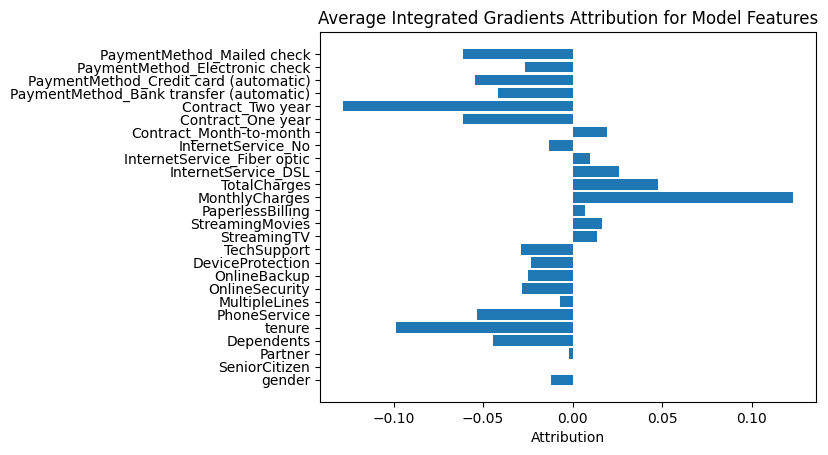

In [76]:
import torch
from captum.attr import IntegratedGradients
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Define the Integrated Gradients explainer
ig = IntegratedGradients(model)

# Function to get the average attributions for the entire dataset
def explain_model(X_data, y_data):
    total_attributions = torch.zeros(X_data.shape[1])
    predictions = []
    attributions_list = []

    for i in range(X_data.shape[0]):
        input_sample = torch.tensor(X_data.iloc[i].values, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
        
        # Generate the attribution for the input sample
        attributions, delta = ig.attribute(input_sample, target=0, return_convergence_delta=True)
        
        # Accumulate the attributions for averaging
        total_attributions += attributions.squeeze()  # Remove extra dimension
        
        # Get model prediction
        prediction = model(input_sample).item()  # Single prediction for the sample
        predictions.append(prediction)
        
        # Save the attributions for later comparison
        attributions_list.append(attributions.squeeze().detach().numpy())

    # Average the attributions across all samples
    average_attributions = total_attributions / X_data.shape[0]

    return np.array(predictions), np.array(attributions_list), average_attributions

# Get the model predictions and attributions for the entire test set
predictions, attributions_list, average_attributions = explain_model(X_test_sap, y_test_sap)

# Measure Faithfulness (Correlation between predictions and summed attributions for each sample)
summed_attributions = np.sum(attributions_list, axis=1)  # Sum the attributions for each sample

# Compute Pearson correlation between the predictions and the summed attributions
faithfulness_score, _ = pearsonr(predictions, summed_attributions)

# Print the faithfulness score
print(f"Faithfulness Score (Pearson Correlation between predictions and summed attributions): {faithfulness_score:.4f}")

# Print the attributions for each feature
print("Average attributions for each feature:")
for feature, attribution in zip(X_test_sap.columns, average_attributions):
    print(f"Feature: {feature}, Attribution: {attribution:.4f}")

# Visualize the average attributions
plt.barh(X_test_sap.columns, average_attributions)
plt.xlabel('Attribution')
plt.title('Average Integrated Gradients Attribution for Model Features')
plt.show()


Faithfulness Score (Pearson Correlation): 0.6158
Faithfulness Score (Spearman's Rank Correlation): 0.9020
Faithfulness Score (Kendall's Tau): 0.7177
Average attributions for each feature:
Feature: gender, Attribution: -0.0121
Feature: SeniorCitizen, Attribution: 0.0002
Feature: Partner, Attribution: -0.0017
Feature: Dependents, Attribution: -0.0442
Feature: tenure, Attribution: -0.0986
Feature: PhoneService, Attribution: -0.0533
Feature: MultipleLines, Attribution: -0.0069
Feature: OnlineSecurity, Attribution: -0.0285
Feature: OnlineBackup, Attribution: -0.0250
Feature: DeviceProtection, Attribution: -0.0234
Feature: TechSupport, Attribution: -0.0286
Feature: StreamingTV, Attribution: 0.0139
Feature: StreamingMovies, Attribution: 0.0167
Feature: PaperlessBilling, Attribution: 0.0070
Feature: MonthlyCharges, Attribution: 0.1234
Feature: TotalCharges, Attribution: 0.0476
Feature: InternetService_DSL, Attribution: 0.0257
Feature: InternetService_Fiber optic, Attribution: 0.0097
Feature: I

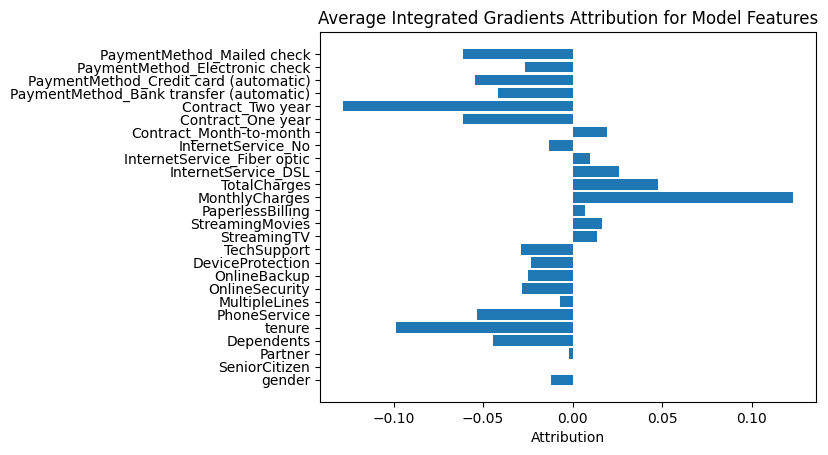

In [96]:
import torch
from captum.attr import IntegratedGradients
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Define the Integrated Gradients explainer
ig = IntegratedGradients(model)

# Function to get the average attributions for the entire dataset
def explain_model(X_data):
    total_attributions = torch.zeros(X_data.shape[1])
    predictions = []
    attributions_list = []

    for i in range(X_data.shape[0]):
        input_sample = torch.tensor(X_data.iloc[i].values, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
        
        # Generate the attribution for the input sample
        attributions, delta = ig.attribute(input_sample, target=0, return_convergence_delta=True)
        
        # Accumulate the attributions for averaging
        total_attributions += attributions.squeeze()  # Remove extra dimension
        
        # Get model prediction
        prediction = model(input_sample).item()  # Single prediction for the sample
        predictions.append(prediction)
        
        # Save the attributions for later comparison
        attributions_list.append(attributions.squeeze().detach().numpy())

    # Average the attributions across all samples
    average_attributions = total_attributions / X_data.shape[0]

    return np.array(predictions), np.array(attributions_list), average_attributions

# Get the model predictions and attributions for the entire test set
predictions, attributions_list, average_attributions = explain_model(X_test_sap)

# Identify the top attributes based on their average attributions
num_top_attributes_to_remove = 5  # You can modify this number based on your needs
top_attributes_indices = np.argsort(-average_attributions)[:num_top_attributes_to_remove]

# Remove the top attributes from the dataset
X_test_sap_reduced = X_test_sap.drop(X_test_sap.columns[top_attributes_indices], axis=1)

# Function to pad reduced input tensor to match the original input size
def pad_input(input_tensor, original_size, removed_indices):
    padding_tensor = torch.zeros((input_tensor.size(0), original_size))
    current_index = 0
    for i in range(original_size):
        if i in removed_indices:
            padding_tensor[:, i] = 0.0  # Fill removed feature positions with 0
        else:
            padding_tensor[:, i] = input_tensor[:, current_index]
            current_index += 1
    return padding_tensor

# Pad the reduced input tensor
reduced_input_tensor = torch.tensor(X_test_sap_reduced.values, dtype=torch.float32)
padded_input_tensor = pad_input(reduced_input_tensor, X_test_sap.shape[1], top_attributes_indices)

# Get model predictions for the padded input tensor
def get_model_predictions(X_data):
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(X_data.shape[0]):
            input_sample = X_data[i].unsqueeze(0)  # Add batch dimension
            prediction = model(input_sample).item()  # Single prediction for the sample
            predictions.append(prediction)
    return np.array(predictions)

# Get model predictions for the reduced test set
predictions_reduced = get_model_predictions(padded_input_tensor)

# Compute Faithfulness using different correlation metrics
# Pearson correlation
pearson_score, _ = pearsonr(predictions, predictions_reduced)

# Spearman's rank correlation
spearman_score, _ = spearmanr(predictions, predictions_reduced)

# Kendall's Tau
kendall_score, _ = kendalltau(predictions, predictions_reduced)

# Print the faithfulness scores
print(f"Faithfulness Score (Pearson Correlation): {pearson_score:.4f}")
print(f"Faithfulness Score (Spearman's Rank Correlation): {spearman_score:.4f}")
print(f"Faithfulness Score (Kendall's Tau): {kendall_score:.4f}")

# Print the attributions for each feature
print("Average attributions for each feature:")
for feature, attribution in zip(X_test_sap.columns, average_attributions):
    print(f"Feature: {feature}, Attribution: {attribution:.4f}")

# Visualize the average attributions
plt.barh(X_test_sap.columns, average_attributions)
plt.xlabel('Attribution')
plt.title('Average Integrated Gradients Attribution for Model Features')
plt.show()


Initial Accuracy: 0.9377
Removed feature MonthlyCharges, Accuracy: 0.8633
Removed feature TotalCharges, Accuracy: 0.8372
Removed feature InternetService_DSL, Accuracy: 0.8392
Removed feature Contract_Month-to-month, Accuracy: 0.7327
Removed feature StreamingMovies, Accuracy: 0.6925
Removed feature StreamingTV, Accuracy: 0.6513
Removed feature InternetService_Fiber optic, Accuracy: 0.5497
Removed feature PaperlessBilling, Accuracy: 0.5407
Removed feature SeniorCitizen, Accuracy: 0.5447
Removed feature Partner, Accuracy: 0.5457
Removed feature MultipleLines, Accuracy: 0.5508
Removed feature gender, Accuracy: 0.6080
Removed feature InternetService_No, Accuracy: 0.6101
Removed feature DeviceProtection, Accuracy: 0.6281
Removed feature OnlineBackup, Accuracy: 0.6503
Removed feature PaymentMethod_Electronic check, Accuracy: 0.7618
Removed feature OnlineSecurity, Accuracy: 0.7638
Removed feature TechSupport, Accuracy: 0.7668
Removed feature PaymentMethod_Bank transfer (automatic), Accuracy: 0

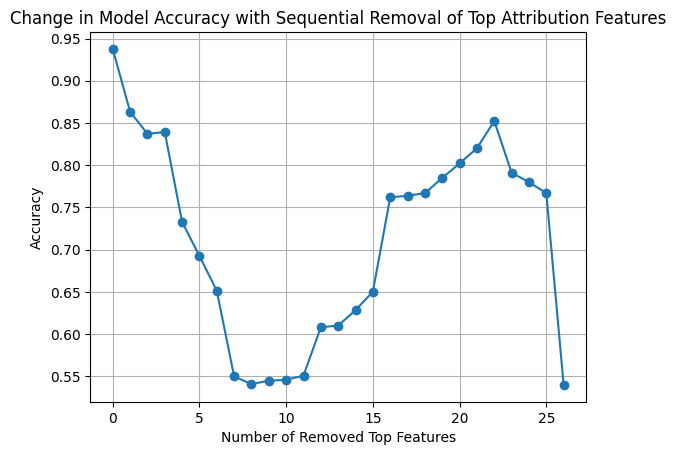

In [103]:
import torch
from captum.attr import IntegratedGradients
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Integrated Gradients explainer
ig = IntegratedGradients(model)

# Function to get the average attributions for the entire dataset
def explain_model(X_data):
    total_attributions = torch.zeros(X_data.shape[1])
    for i in range(X_data.shape[0]):
        input_sample = torch.tensor(X_data.iloc[i].values, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
        
        # Generate the attribution for the input sample
        attributions, delta = ig.attribute(input_sample, target=0, return_convergence_delta=True)
        
        # Accumulate the attributions for averaging
        total_attributions += attributions.squeeze()  # Remove extra dimension

    # Average the attributions across all samples
    average_attributions = total_attributions / X_data.shape[0]

    return average_attributions.detach().numpy()

# Calculate the attributions for the test set
average_attributions = explain_model(X_test_sap)

# Identify the top attributes based on their average attributions
top_attributes_indices = np.argsort(-average_attributions)  # Sorted indices of features based on attributions

# Function to pad reduced input tensor to match the original input size
def pad_input(input_tensor, original_size, removed_indices):
    padding_tensor = torch.zeros((input_tensor.size(0), original_size))
    current_index = 0
    for i in range(original_size):
        if i in removed_indices:
            padding_tensor[:, i] = 0.0  # Fill removed feature positions with 0
        else:
            padding_tensor[:, i] = input_tensor[:, current_index]
            current_index += 1
    return padding_tensor

# Function to measure accuracy
def measure_accuracy(X_data, y_data, removed_indices):
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(X_data.values, dtype=torch.float32)
        padded_inputs = pad_input(inputs, original_size=X_test_sap.shape[1], removed_indices=removed_indices)
        outputs = model(padded_inputs)
        preds = (outputs > 0.5).float().squeeze()
        accuracy = (preds == torch.tensor(y_data.values)).float().mean().item()
    return accuracy

# Measure initial accuracy
initial_accuracy = measure_accuracy(X_test_sap, y_test_sap, removed_indices=[])
print(f"Initial Accuracy: {initial_accuracy:.4f}")

# Sequentially remove top features and measure accuracy
accuracies = [initial_accuracy]
removed_features = []

for idx in top_attributes_indices:
    removed_features.append(X_test_sap.columns[idx])
    X_test_sap_reduced = X_test_sap.drop(columns=removed_features)
    accuracy = measure_accuracy(X_test_sap_reduced, y_test_sap, removed_indices=top_attributes_indices[:len(removed_features)])
    accuracies.append(accuracy)
    print(f"Removed feature {X_test_sap.columns[idx]}, Accuracy: {accuracy:.4f}")

# Plot the change in accuracy
plt.plot(range(len(accuracies)), accuracies, marker='o')
plt.xlabel('Number of Removed Top Features')
plt.ylabel('Accuracy')
plt.title('Change in Model Accuracy with Sequential Removal of Top Attribution Features')
plt.grid(True)
plt.show()


# Protodash

In [104]:
from aix360.algorithms.protodash import ProtodashExplainer

In [105]:
df2.shape

(7043, 27)

In [106]:
X.shape

(7043, 26)

In [107]:
X_train.shape

(5634, 26)

In [108]:
X_test.shape

(1409, 26)

In [109]:
y_train.shape

(5634,)

In [110]:
y_test.shape

(1409,)

In [111]:
# Initialize the Protodash Explainer
explainer = ProtodashExplainer()

# Set parameters for the explainer
explainer.set_params(kernelType='Gaussian', sigma=1.0, optimizer='cvxpy')

# Generate explanations
m = 10  # Number of prototypes to select
output = explainer.explain(df2.values, df2.values, m)

# Unpack the output based on its structure
prototypes = output[0]           # Current optimal weights (prototypes)
importance_weights = output[1]   # Indices of selected prototypes
additional_info = output[2]      # Objective values or additional information

# Analyze results
print("Selected Prototypes:\n", prototypes)
print("Importance Weights (Indices):\n", importance_weights)
print("Additional Information:\n", additional_info)

Selected Prototypes:
 [0.19435821 0.0824747  0.21534346 0.18083146 0.09079334 0.05758694
 0.07230816 0.05356117 0.0311486  0.01431418]
Importance Weights (Indices):
 [ 635 4295 1839 1464 5545 5070 1042  688  866 3240]
Additional Information:
 [1.62736522 1.85641049 1.96876823 2.06269131 2.08867742 2.09654935
 2.10192524 2.10582201 2.10753825 2.10801186]


In [120]:
from IPython.display import display
ptypes = X.iloc[importance_weights]
display(ptypes)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
635,1,0,1,1,0.902778,1,1,0,1,1,...,0,1,0,1,0,0,0,0,1,0
4295,0,1,1,0,0.930556,1,0,1,1,0,...,1,0,0,0,1,0,1,0,0,0
1839,1,0,0,0,0.055556,1,1,0,0,0,...,0,0,1,0,0,1,0,1,0,0
1464,0,0,0,0,0.125000,1,0,1,0,0,...,1,0,0,1,0,0,0,0,0,1
5545,0,1,1,0,0.291667,1,0,0,0,1,...,0,1,0,1,0,0,1,0,0,0
5070,0,0,0,1,0.486111,1,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
1042,1,0,1,1,0.194444,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
688,0,0,0,0,0.722222,0,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
866,0,0,1,0,0.861111,0,0,0,0,0,...,1,0,0,0,0,1,1,0,0,0
3240,1,0,1,0,0.750000,1,1,1,1,0,...,0,1,0,0,1,0,1,0,0,0


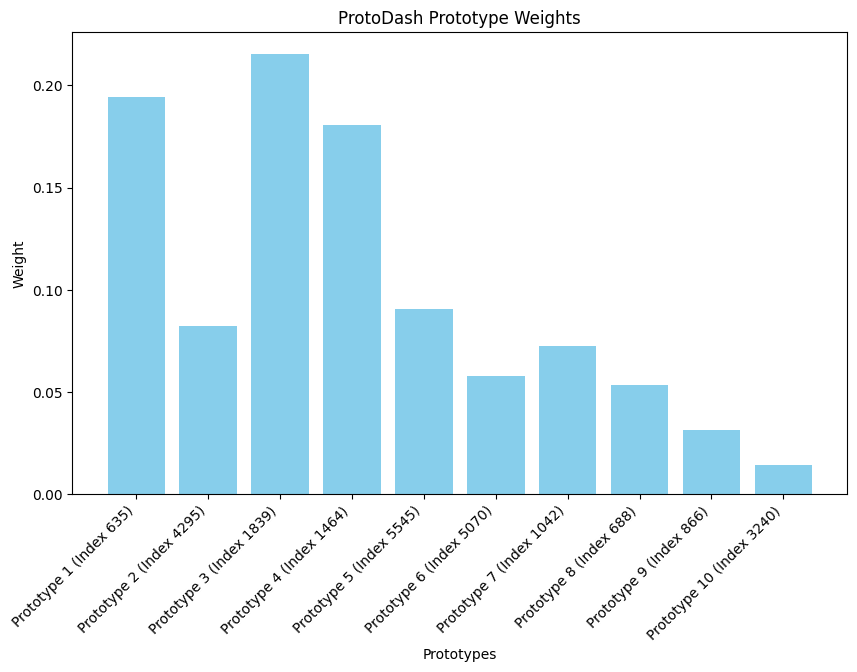

In [113]:
import matplotlib.pyplot as plt

# Assume prototype_weights is the list of weights for each prototype
# Assume prototype_indices is the list of indices for each prototype
num_prototypes = len(prototypes)
labels = [f"Prototype {i+1} (Index {idx})" for i, idx in enumerate(importance_weights)]

plt.figure(figsize=(10, 6))
plt.bar(labels, prototypes, color='skyblue')
plt.xlabel("Prototypes")
plt.ylabel("Weight")
plt.title("ProtoDash Prototype Weights")
plt.xticks(rotation=45, ha="right")
plt.show()


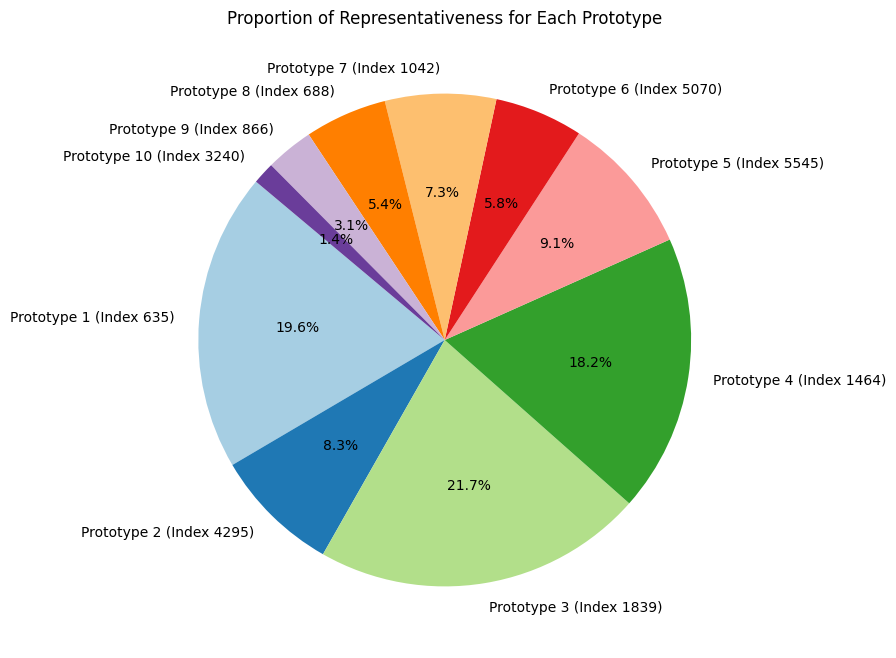

In [114]:
plt.figure(figsize=(8, 8))
plt.pie(prototypes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Proportion of Representativeness for Each Prototype")
plt.show()


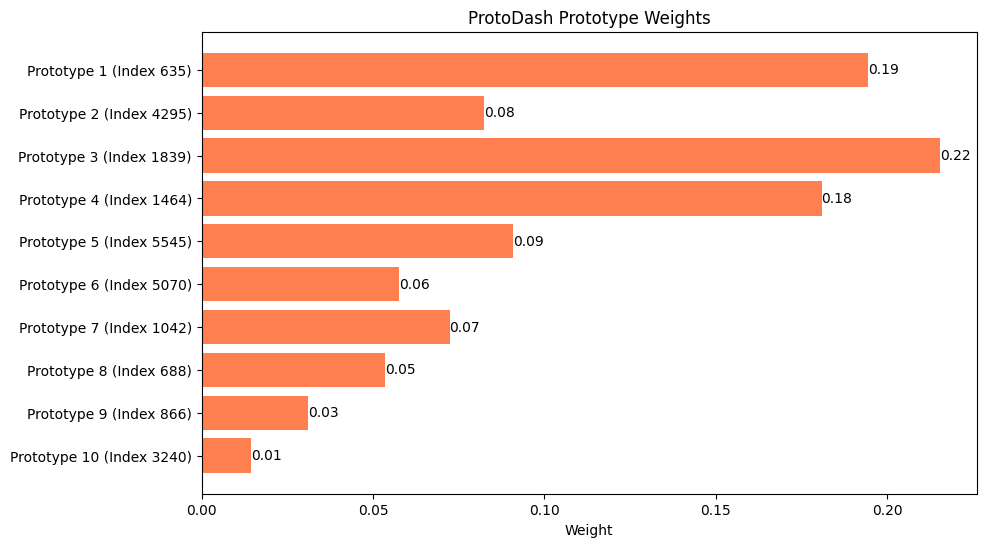

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.barh(labels, prototypes, color='coral')
plt.xlabel("Weight")
plt.title("ProtoDash Prototype Weights")
plt.gca().invert_yaxis()  # Reverse the order for better readability

# Annotating each bar with its value
for bar in bars:
    width = bar.get_width()  # Get the width of the bar (i.e., the prototype value)
    plt.text(width, bar.get_y() + bar.get_height() / 2,  # Position the text beside the bar
             f'{width:.2f}',  # Display value formatted to 2 decimal places
             va='center', ha='left', color='black')  # Align the text

plt.show()


In [117]:
feature_names=df2.columns.to_list()

In [118]:
feature_names

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Bank transfer (automatic)',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

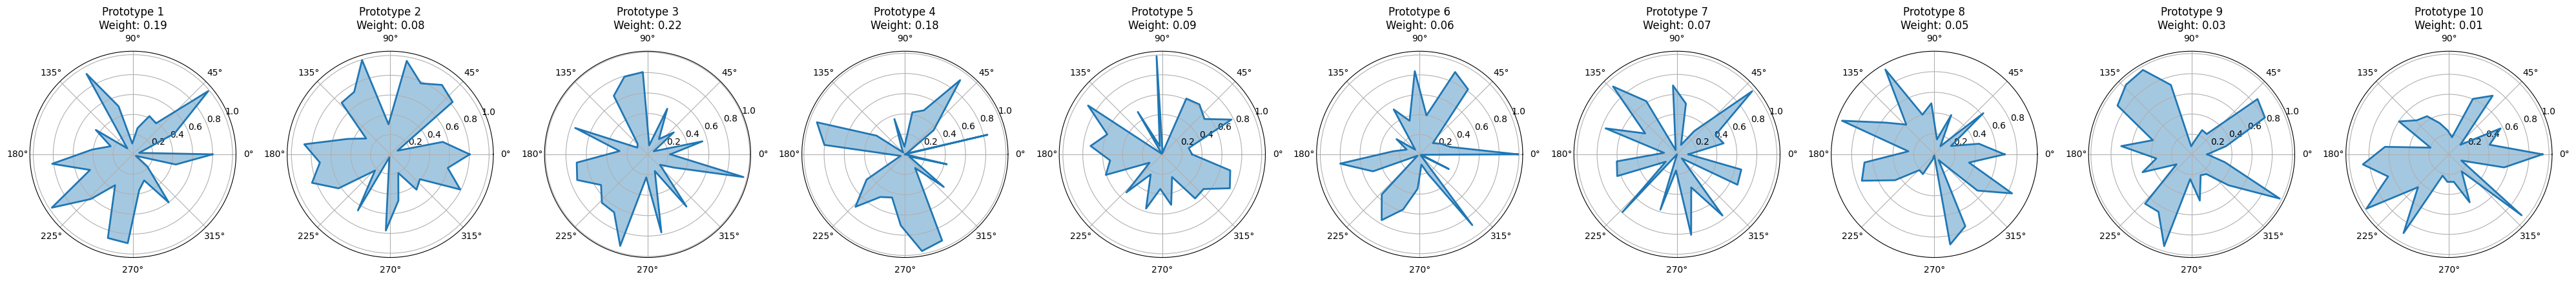

In [119]:
from math import pi

feature_data = np.random.rand(num_prototypes, len(feature_names))  # Replace with actual feature values

# Create radar chart for each prototype
fig, axs = plt.subplots(1, m, figsize=(m * 4, 4), subplot_kw=dict(polar=True))
for i, (ax, prototypes) in enumerate(zip(axs, prototypes)):
    values = feature_data[i]
    values = np.append(values, values[0])  # Complete the loop
    angles = [n / float(len(feature_names)) * 2 * pi for n in range(len(feature_names))]
    angles += angles[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid')
    ax.fill(angles, values, alpha=0.4)
    ax.set_title(f"Prototype {i+1}\nWeight: {prototypes:.2f}")

# Adjust layout and display plot
plt.tight_layout()
plt.show()